# Metoda C — Screen identycznosci + VisDiff proposer

Pipeline laczacy **B2T** (Kim et al. 2024) z **VisDiff** (Dunlap et al. 2024):
1. Qwen ocenia czy para jest identyczna (YES/NO) — inspiracja B2T
2. Identyczne pary: `No_Difference`
3. Rozne pary: pelny pipeline Metody A (VisDiff proposer)

---

## 0. Instalacja

In [ ]:
!pip install transformers accelerate Pillow tqdm -q
!pip install salesforce-lavis -q 2>/dev/null || echo 'LAVIS niedostepny'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 16.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

## 1. Importy

In [ ]:
import os, gc, json, math, textwrap
from pathlib import Path
import torch
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display as ipy_display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from transformers import (
    Qwen2VLForConditionalGeneration, AutoProcessor,
    Blip2Processor, Blip2ForConditionalGeneration,
)
from datasets import load_dataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urzadzenie: {DEVICE}")

Urzadzenie: cuda


## 2. Konfiguracja

In [ ]:
import os
REPO_NAME = "vision_blindspots"
REPO_URL = "https://github.com/aprzezdziecka/vision_blindspots.git"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

%cd {REPO_NAME}

Cloning into 'vision_blindspots'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 102 (delta 48), reused 13 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 20.29 MiB | 8.73 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/vision_blindspots


In [ ]:
BASE_SCORE_MIN = 0.95
REF_SCORE_MAX  = 0.65   # chociaz JEDEN ref score ponizej progu
MAX_PAIRS      = 5

CACHE_DIR = Path("/content/img_cache")

CSV_FILES = {
    "Caltech101": [
        {"path": "/content/vision_blindspots/clip_caltech_blind_spots.csv",    "model": "CLIP"},
        {"path": "/content/vision_blindspots/siglip_caltech_blind_spots.csv",  "model": "SigLIP"},
        {"path": "/content/vision_blindspots/dino_caltech_blind_spots.csv",    "model": "DINOv2"},
        {"path": "/content/vision_blindspots/siglip2_caltech_blind_spots.csv", "model": "SigLIP2"},
    ],
    "ImageNet-test": [
        {"path": "/content/vision_blindspots/clip_imagenet_test_blind_spots.csv",    "model": "CLIP"},
        {"path": "/content/vision_blindspots/siglip_imagenet_test_blind_spots.csv",  "model": "SigLIP"},
        {"path": "/content/vision_blindspots/dino_imagenet_test_blind_spots.csv",    "model": "DINOv2"},
        {"path": "/content/vision_blindspots/siglip2_imagenet_test_blind_spots.csv", "model": "SigLIP2"},
    ],
}

CATEGORIES = [
    "Orientation_And_Direction", "Presence_Of_Features", "State_And_Condition",
    "Quantity_And_Count", "Positional_Context", "Color_And_Appearance",
    "Structural_Characteristics", "Text", "Viewpoint_Perspective", "No_Difference",
]
print("Konfiguracja zaladowana.")

Konfiguracja zaladowana.


## 3. Logowanie HuggingFace

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 4. Wczytanie datasetow

In [ ]:
def add_index(sample, idx):
    sample["id"] = idx
    return sample

print("Wczytywanie Caltech101...")
ds_caltech = load_dataset("flwrlabs/caltech101", split="train", trust_remote_code=True)
print("  v Caltech101")

print("Wczytywanie ImageNet-1k (test, streaming)...")
ds_imagenet = load_dataset("ILSVRC/imagenet-1k", split="test", streaming=True)
ds_imagenet = ds_imagenet.map(add_index, with_indices=True)
print("  v ImageNet-test (streaming)")

DATASETS = {"Caltech101": ds_caltech, "ImageNet-test": ds_imagenet}

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flwrlabs/caltech101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flwrlabs/caltech101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Wczytywanie Caltech101...
  v Caltech101
Wczytywanie ImageNet-1k (test, streaming)...


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

  v ImageNet-test (streaming)


## 5. Filtrowanie par

> `base_score > 0.95` ORAZ **chociaz jeden** z `ref_1_score`, `ref_2_score` ponizej `0.65`

In [ ]:
def filter_blind_spots(path, base_min, ref_max, max_pairs):
    # Kryterium: base pewny ORAZ chociaz jeden ref sie nie zgadza
    df = pd.read_csv(path, sep=";")
    mask = (
        (df["score_base"] > base_min) &
        ((df["score_ref_1"] < ref_max) | (df["score_ref_2"] < ref_max))
    )
    return df[mask].head(max_pairs).reset_index(drop=True)

filtered = {}
summary_rows = []
for dataset_name, configs in CSV_FILES.items():
    filtered[dataset_name] = {}
    for cfg in configs:
        df_f = filter_blind_spots(cfg["path"], BASE_SCORE_MIN, REF_SCORE_MAX, MAX_PAIRS)
        filtered[dataset_name][cfg["model"]] = df_f
        summary_rows.append({"Dataset": dataset_name, "Model": cfg["model"],
                              "Blind spots": len(df_f)})

ipy_display(pd.DataFrame(summary_rows).style.hide(axis="index"))

Dataset,Model,Blind spots
Caltech101,CLIP,5
Caltech101,SigLIP,3
Caltech101,DINOv2,5
Caltech101,SigLIP2,5
ImageNet-test,CLIP,5
ImageNet-test,SigLIP,5
ImageNet-test,DINOv2,5
ImageNet-test,SigLIP2,5


## 6. Cache obrazkow

In [ ]:
def prefetch_pairs(df_pairs, dataset, dataset_name):
    ids = set(df_pairs["id_1"].astype(int)) | set(df_pairs["id_2"].astype(int))
    out_dir = CACHE_DIR / dataset_name
    out_dir.mkdir(parents=True, exist_ok=True)
    missing = {i for i in ids if not (out_dir / f"{i}.jpg").exists()}
    if missing:
        print(f"  Pobieram {len(missing)} obrazkow dla {dataset_name}...")
        if dataset_name == "Caltech101":
            for i in tqdm(missing):
                dataset[i]["image"].convert("RGB").save(out_dir / f"{i}.jpg", "JPEG")
        else:
            max_id = max(missing)
            for cur, sample in enumerate(tqdm(iter(dataset), total=max_id+1)):
                if cur in missing:
                    sample["image"].convert("RGB").save(out_dir / f"{cur}.jpg", "JPEG")
                    missing.discard(cur)
                if cur >= max_id or not missing:
                    break
    else:
        print(f"  [{dataset_name}] Wszystko w cache.")

print("Pobieranie obrazkow...")
for dsn, model_dfs in filtered.items():
    all_pairs = pd.concat(model_dfs.values(), ignore_index=True)
    if not all_pairs.empty:
        prefetch_pairs(all_pairs, DATASETS[dsn], dsn)
print("Gotowe.")

Pobieranie obrazkow...
  Pobieram 24 obrazkow dla Caltech101...


  0%|          | 0/24 [00:00<?, ?it/s]

  Pobieram 34 obrazkow dla ImageNet-test...


  0%|          | 0/99760 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Gotowe.


## 7. Ladowanie modeli

In [ ]:
QWEN_ID = "Qwen/Qwen2-VL-2B-Instruct"

print(f"Ladowanie Qwena ({QWEN_ID})...")
qwen_processor = AutoProcessor.from_pretrained(QWEN_ID)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
qwen_model.eval()
print("  v Qwen gotowy")

Ladowanie Qwena (Qwen/Qwen2-VL-2B-Instruct)...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

  v Qwen gotowy


## 8. Funkcje pomocnicze i prompty z artykulow

> **Zrodla promptow:**
> - Caption-based proposer: VisDiff Figure 10 (top)
> - Image-based ranker (VQA): VisDiff Figure 10 (middle) — format `Question: ... Answer:`
> - Kategoryzacja: wspolny CATEGORIZE_PROMPT

In [ ]:
# =========================================================
# PROMPTY Z ARTYKULOW
# =========================================================

# VisDiff (Figure 10, top): caption-based proposer
# Oryginalnie uzywany z GPT-4 na zbiorach; adaptujemy do pary
VISDIFF_PROPOSER_PROMPT = (
    "The following are the result of captioning two images:\n\n"
    "Image 1: {cap1}\n"
    "Image 2: {cap2}\n\n"
    "I am a machine learning researcher trying to figure out the major differences "
    "between these two images so I can better understand my data.\n"
    "Come up with concepts that are more likely to be true for Image 1 compared to "
    "Image 2. Write a list of captions (separated by bullet points '*'). For example:\n"
    "* \"a dog next to a horse\"\n"
    "* \"a car in the rain\"\n"
    "* \"cars from a side view\"\n\n"
    "Do not list more than one concept per bullet. Hypotheses like \"more of ...\"\n"
    "\"presence of ...\", \"images with ...\" are incorrect. Examples of corrections:\n"
    "* INCORRECT: \"various nature environments like lakes, forests, and mountains\" "
    "CORRECTED: \"nature\"\n"
    "* INCORRECT: \"Presence of baby animals\" CORRECTED: \"baby animals\"\n"
    "* INCORRECT: \"More realistic images\" CORRECTED: \"realistic images\"\n\n"
    "List properties that hold more often for Image 1 than Image 2. "
    "Answer with bullet points '*' ONLY. Your response:"
)

# VisDiff (Figure 10, bottom): caption-based ranker prompt
# Uzywamy do walidacji czy dany koncept pasuje do caption
# VISDIFF_RANKER_PROMPT = (
#     "Given a caption and a concept, respond with yes or no.\n\n"
#     "Caption: \"{caption}\"\n"
#     "Concept: \"{concept}\"\n\n"
#     "Does the caption support the concept? Answer with yes or no ONLY.\n"
#     "OUTPUT:"
# )
VISDIFF_PROPOSER_PROMPT = (
    "The following are the result of captioning two images:\n\n"
    "Image 1: {cap1}\n"
    "Image 2: {cap2}\n\n"
    "I am a machine learning researcher trying to figure out the EXACT differences "
    "between these two images. You must ONLY list things that are present in Image 1 BUT ABSENT in Image 2.\n"
    "CRITICAL RULE: DO NOT list objects, subjects, or backgrounds that exist in both images (e.g., if both have a jaguar, DO NOT list 'jaguar'). "
    "If the images describe the exact same main subjects and scene, output exactly: * \"no significant differences\"\n\n"
    "Answer with bullet points '*' ONLY. Your response:"
)

# Kategoryzacja roznic (wspolna dla A, B, C)
CATEGORIZE_PROMPT = (
    "Based on the following description of differences between two images, "
    "classify which categories apply.\n"
    "Respond ONLY with a valid JSON object. Example format:\n"
    "{{\n"
    "  \"Presence_Of_Features\": 1,\n"
    "  \"Color_And_Appearance\": 0\n"
    "}}\n"
    "Do not include markdown formatting or explanations.\n\n"
    "Categories (1 = applies, 0 = does not apply):\n"
    "- Orientation_And_Direction: object facing differently, flipped, or rotated\n"
    "- Presence_Of_Features: specific part added or missing (glasses, handle, leaf...)\n"
    "- State_And_Condition: different state (open/closed, broken/whole, wet/dry...)\n"
    "- Quantity_And_Count: number of objects differs\n"
    "- Positional_Context: objects placed differently relative to background\n"
    "- Color_And_Appearance: changes in colors, lighting, or vibrancy\n"
    "- Structural_Characteristics: core shape, material, or build is different\n"
    "- Text: differences in words, numbers, or logos\n"
    "- Viewpoint_Perspective: camera angle, zoom, or framing differs\n"
    "- No_Difference: the images are essentially identical\n\n"
    "Description:\n{description}\n\nJSON:"
)

# =========================================================
# FUNKCJE POMOCNICZE
# =========================================================

def qwen_infer(images_list, prompt_text, max_new_tokens=512):
    content = [{"type": "image", "image": img} for img in images_list]
    content.append({"type": "text", "text": prompt_text})
    messages = [{"role": "user", "content": content}]
    text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    imgs = images_list if images_list else None
    inputs = qwen_processor(text=[text], images=imgs, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        gen = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens)
    trimmed = gen[0][inputs.input_ids.shape[1]:]
    del inputs, gen; torch.cuda.empty_cache()
    return qwen_processor.decode(trimmed, skip_special_tokens=True).strip()


def parse_categories(raw_text):
    clean = raw_text.strip()

    for fence in ["```json", "```"]:
        if clean.startswith(fence):
            clean = clean[len(fence):]
    if clean.endswith("```"):
        clean = clean[:-3]

    start = clean.find("{")
    end = clean.rfind("}") + 1
    if start >= 0 and end > start:
        clean = clean[start:end]

    try:
        parsed = json.loads(clean)

        wyniki = {k: int(bool(parsed.get(k, 0))) for k in CATEGORIES}

        inne_kategorie = [k for k in CATEGORIES if k != "No_Difference"]
        suma_roznic = sum(wyniki[k] for k in inne_kategorie)

        if suma_roznic > 0:
            wyniki["No_Difference"] = 0

        return wyniki

    except json.JSONDecodeError:
        return {k: None for k in CATEGORIES}


def load_pair_images(row, dataset_name):
    id1, id2 = int(row["id_1"]), int(row["id_2"])
    img1 = Image.open(CACHE_DIR / dataset_name / f"{id1}.jpg").convert("RGB")
    img2 = Image.open(CACHE_DIR / dataset_name / f"{id2}.jpg").convert("RGB")
    return img1, img2


def stitch_images(img1, img2, gap=10):
    h = max(img1.height, img2.height)
    w = img1.width + gap + img2.width
    canvas = Image.new("RGB", (w, h), (200, 200, 200))
    canvas.paste(img1, (0, 0))
    canvas.paste(img2, (img1.width + gap, 0))
    return canvas


def save_results(results, out_path):
    pd.DataFrame(results).to_csv(
        out_path, mode="a", header=not Path(out_path).exists(), index=False
    )


def run_on_all_files(method_fn, output_csv, label):
    if Path(output_csv).exists(): os.remove(output_csv)
    for dataset_name, model_dfs in filtered.items():
        for model_name, df_pairs in model_dfs.items():
            if df_pairs.empty: continue
            print(f"[{label}] {dataset_name} / {model_name} -- {len(df_pairs)} par")
            results = []
            for _, row in tqdm(df_pairs.iterrows(), total=len(df_pairs)):
                try:
                    res = method_fn(row, dataset_name)
                except Exception as e:
                    print(f"  BLAD {int(row['id_1'])}-{int(row['id_2'])}: {e}")
                    res = {k: None for k in CATEGORIES}; res["error"] = str(e)
                res.update({
                    "dataset_name": dataset_name, "base_name": model_name,
                    "id_1": int(row["id_1"]), "id_2": int(row["id_2"]),
                    "base_score": row.get("score_base"),
                    "ref_1_score": row.get("score_ref_1"),
                    "ref_2_score": row.get("score_ref_2"),
                })
                results.append(res); gc.collect()
            save_results(results, output_csv)
    print(f"  -> Zapisano: {output_csv}")
    return pd.read_csv(output_csv)


# def show_results(df, desc_col="diff_bullets", dataset_name=None, model_name=None, n=3):
#     df_f = df.copy()
#     if dataset_name: df_f = df_f[df_f["dataset_name"] == dataset_name]
#     if model_name:   df_f = df_f[df_f["base_name"] == model_name]
#     sample = df_f.sample(n=min(n, len(df_f))).reset_index(drop=True)
#     for _, row in sample.iterrows():
#         ds = row["dataset_name"]
#         fig = plt.figure(figsize=(10, 4))
#         gs  = gridspec.GridSpec(2, 2, height_ratios=[4, 1.5])
#         for col, id_col in enumerate(["id_1", "id_2"]):
#             ax = fig.add_subplot(gs[0, col])
#             ax.imshow(Image.open(CACHE_DIR / ds / f"{int(row[id_col])}.jpg"))
#             ax.set_title(f"ID {int(row[id_col])}", fontsize=9); ax.axis("off")
#         ax_txt = fig.add_subplot(gs[1, :]); ax_txt.axis("off")
#         desc = textwrap.fill(str(row.get(desc_col, "---")), width=110)
#         ax_txt.text(0.5, 0.5, desc, ha="center", va="center", fontsize=8,
#                     bbox=dict(facecolor="#f5f5f5", edgecolor="#ccc", boxstyle="round,pad=0.5"))
#         cats = [c for c in CATEGORIES if row.get(c) == 1]
#         plt.suptitle(f"{ds} - {row['base_name']}\nKategorie: {', '.join(cats) or '---'}",
#                      fontsize=9, fontweight="bold")
#         plt.tight_layout(); plt.show(); print("-" * 80)


# def plot_category_bars(df, title):
#     for cat in CATEGORIES:
#         df[cat] = pd.to_numeric(df[cat], errors="coerce").fillna(0).astype(int)
#     grouped = df.groupby("base_name")[CATEGORIES].sum()
#     counts  = df.groupby("base_name").size()
#     normed  = (grouped.div(counts, axis=0) * 100).round(1)
#     ax = normed.plot(kind="bar", figsize=(14, 5), width=0.8)
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     ax.set_xlabel("Model bazowy"); ax.set_ylabel("% par")
#     ax.legend(title="Kategoria", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
#     plt.tight_layout(); plt.show()
#     return normed

def show_results(df, desc_col="diff_bullets", dataset_name=None, model_name=None, n=3):
  df_f = df.copy()

  if dataset_name:
      df_f = df_f[df_f["dataset_name"] == dataset_name]
  if model_name:
      df_f = df_f[df_f["base_name"] == model_name]

  sample = df_f.sample(n=min(n, len(df_f))).reset_index(drop=True)

  for _, row in sample.iterrows():
      ds = row["dataset_name"]

      fig = plt.figure(figsize=(10, 4))
      gs  = gridspec.GridSpec(2, 2, height_ratios=[4, 1.5])

      for col, id_col in enumerate(["id_1", "id_2"]):
          ax = fig.add_subplot(gs[0, col])
          try:
              ax.imshow(Image.open(CACHE_DIR / ds / f"{int(row[id_col])}.jpg"))
          except Exception as e:
              print(f"Nie znaleziono zdjęcia: {CACHE_DIR / ds / f'{int(row[id_col])}.jpg'}")
          ax.set_title(f"ID {int(row[id_col])}", fontsize=9)
          ax.axis("off")

      ax_txt = fig.add_subplot(gs[1, :])
      ax_txt.axis("off")

      desc = textwrap.fill(str(row.get(desc_col, "---")), width=110)
      ax_txt.text(0.5, 0.5, desc, ha="center", va="center", fontsize=8,
                  bbox=dict(facecolor="#f5f5f5", edgecolor="#ccc", boxstyle="round,pad=0.5"))

      cats = [c for c in CATEGORIES if row.get(c) == 1]

      plt.suptitle(f"{ds} - {row['base_name']}\nKategorie: {', '.join(cats) or '---'}",
                  fontsize=9, fontweight="bold")

      plt.tight_layout()
      plt.show()
      print("-" * 80)


def plot_category_bars(df, title):
    for cat in CATEGORIES:
        df[cat] = pd.to_numeric(df[cat], errors="coerce").fillna(0).astype(int)

    grouped = df.groupby("base_name")[CATEGORIES].sum()
    counts  = df.groupby("base_name").size()
    normed  = (grouped.div(counts, axis=0) * 100).round(1)

    ax = normed.plot(kind="bar", figsize=(14, 5), width=0.8)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Model bazowy")
    ax.set_ylabel("% par")
    ax.legend(title="Kategoria", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

    return normed

## 9. Metoda C — implementacja

In [ ]:
# =========================================================
# METODA C: Screen identycznosci (Qwen) -> Metoda A dla roznych par
#
# Zrodlo: B2T (Kim et al. 2024) -- inspiracja dla wstepnego screeningu:
#   zanim szukamy roznic, sprawdzamy czy obrazki nie sa takie same.
#   Qwen widzi oba obrazy i odpowiada YES/NO.
# Dla nieidentycznych par: pelny pipeline Metody A (VisDiff proposer).
# =========================================================

IDENTITY_PROMPT = (
    "Look at these two images carefully.\n"
    "Are they essentially identical -- same subject, same scene, "
    "no meaningful visual differences?\n"
    "Answer with exactly one word: YES or NO."
)


def is_identical_qwen(img1, img2):
    answer = qwen_infer([img1, img2], IDENTITY_PROMPT, max_new_tokens=5)
    return answer.strip().upper().startswith("YES")


def run_method_a_on_images(img1, img2):
    # Pipeline Metody A bez ladowania z dysku
    qwen1 = qwen_infer([img1], "Describe this image in detail.", max_new_tokens=200)
    qwen2 = qwen_infer([img2], "Describe this image in detail.", max_new_tokens=200)
    cap1  = f"Qwen: {qwen1}"
    cap2  = f"Qwen: {qwen2}"
    diff_bullets = qwen_infer([], VISDIFF_PROPOSER_PROMPT.format(cap1=cap1, cap2=cap2), max_new_tokens=400)
    cat_raw      = qwen_infer([], CATEGORIZE_PROMPT.format(description=diff_bullets), max_new_tokens=300)
    return {
        "qwen_cap_1": qwen1, "qwen_cap_2": qwen2,
        "diff_bullets": diff_bullets,
        **parse_categories(cat_raw),
    }


def method_c(row, dataset_name):
    img1, img2 = load_pair_images(row, dataset_name)

    # Krok 1: czy identyczne?
    identical = is_identical_qwen(img1, img2)

    res = {
        "identical_by_qwen": identical,
        "qwen_cap_1": None,
        "qwen_cap_2": None,
        "diff_bullets": None
    }

    if identical:
        res["diff_bullets"] = "Qwen: images are essentially identical."
        for k in CATEGORIES:
            res[k] = 1 if k == "No_Difference" else 0
    else:
        out_a = run_method_a_on_images(img1, img2)
        res["qwen_cap_1"] = out_a.get("qwen_cap_1")
        res["qwen_cap_2"] = out_a.get("qwen_cap_2")
        res["diff_bullets"] = out_a.get("diff_bullets")
        for k in CATEGORIES:
            res[k] = out_a.get(k)

    return res


results_c = run_on_all_files(method_c, "/content/results_method_C.csv", "Metoda C")
ipy_display(results_c.head(10))

[Metoda C] Caltech101 / CLIP -- 5 par


  0%|          | 0/5 [00:00<?, ?it/s]

[Metoda C] Caltech101 / SigLIP -- 3 par


  0%|          | 0/3 [00:00<?, ?it/s]

[Metoda C] Caltech101 / DINOv2 -- 5 par


...

  0%|          | 0/5 [00:00<?, ?it/s]

[Metoda C] ImageNet-test / SigLIP2 -- 5 par


  0%|          | 0/5 [00:00<?, ?it/s]

  -> Zapisano: /content/results_method_C.csv


,identical_by_qwen,qwen_cap_1,qwen_cap_2,diff_bullets,Orientation_And_Direction,Presence_Of_Features,State_And_Condition,Quantity_And_Count,Positional_Context,Color_And_Appearance,...,Text,Viewpoint_Perspective,No_Difference,dataset_name,base_name,id_1,id_2,base_score,ref_1_score,ref_2_score
0,True,NaN,NaN,Qwen: images are essentially identical.,0,0,0,0,0,0,...,0,0,1,Caltech101,CLIP,20,465,0.961227,0.425818,0.990587
1,False,"The image depicts a jaguar, a large feline nat...","The image depicts a jaguar, a large feline nat...",- The jaguar in Image 1 is walking on a rocky ...,0,0,0,0,0,1,...,0,0,0,Caltech101,CLIP,55,7297,0.987392,0.586700,0.990598
2,False,The image depicts a classic symbol known as th...,The image depicts a classic symbol known as th...,- Yin-Yang symbol\n- Black circle\n- White cir...,0,0,0,0,0,1,...,0,0,0,Caltech101,CLIP,84,8550,0.965167,0.366609,0.748084
3,False,The image depicts a classic symbol known as th...,The image depicts a classic symbol known as th...,- Yin-Yang symbol\n- Yin\n- Yang\n- Yin and Ya...,0,0,0,0,0,0,...,0,0,1,Caltech101,CLIP,84,4583,0.963342,0.417315,0.788334
4,False,"The image depicts a scorpion, specifically a t...","The image depicts a scorpion, specifically a t...","- scorpion\n- elongated, segmented body\n- yel...",0,1,0,0,0,1,...,0,0,0,Caltech101,CLIP,116,5039,0.957302,0.139836,0.982948
5,False,"The image depicts a large commercial airplane,...",The image depicts a commercial airplane in fli...,- Northwest Airlines logo\n- Northwest Airline...,0,0,0,0,0,0,...,0,0,1,Caltech101,SigLIP,561,4776,0.955135,0.684157,0.251779
6,False,The image depicts a commercial airplane in fli...,"The image depicts a small, propeller-driven ai...",- no significant differences,0,0,0,0,0,0,...,0,0,1,Caltech101,SigLIP,5264,5818,0.953968,0.650006,-0.010898
7,False,"The image depicts a small, propeller-driven ai...",The image depicts a commercial airplane in fli...,- no significant differences,0,0,0,0,0,0,...,0,0,1,Caltech101,SigLIP,5818,6132,0.951875,0.642874,-0.000313
8,True,NaN,NaN,Qwen: images are essentially identical.,0,0,0,0,0,0,...,0,0,1,Caltech101,DINOv2,20,465,0.990587,0.425818,0.961227
9,False,"The image depicts a jaguar, a large feline nat...","The image depicts a jaguar, a large feline nat...",- The jaguar in Image 1 is walking on a rocky ...,0,0,0,0,0,1,...,0,0,0,Caltech101,DINOv2,55,7297,0.990598,0.586700,0.987392


### Wyniki i wykres

Odrzucono jako identyczne: 2/38 par (5.3%)


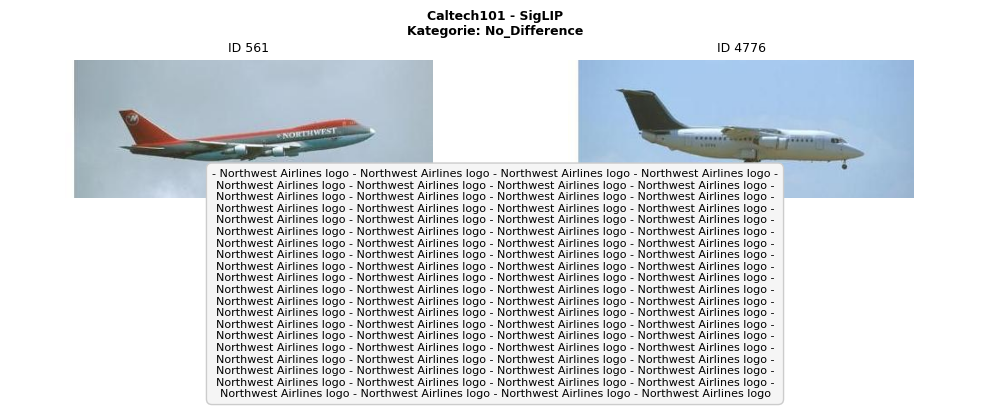

--------------------------------------------------------------------------------


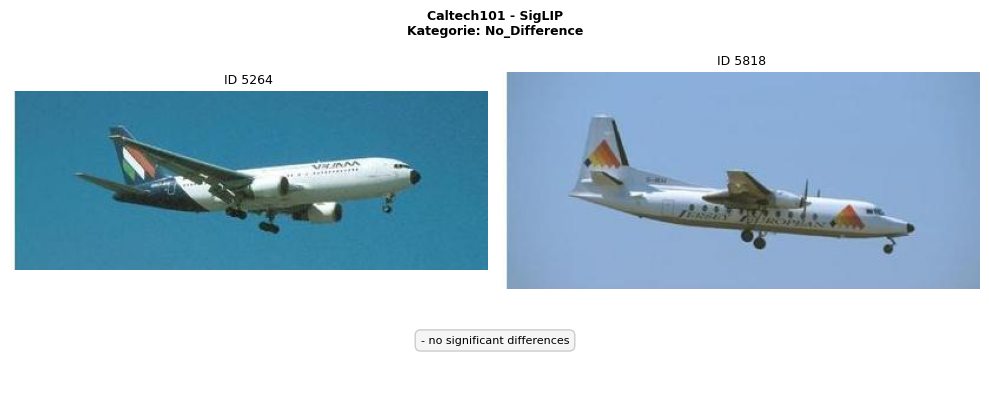

--------------------------------------------------------------------------------


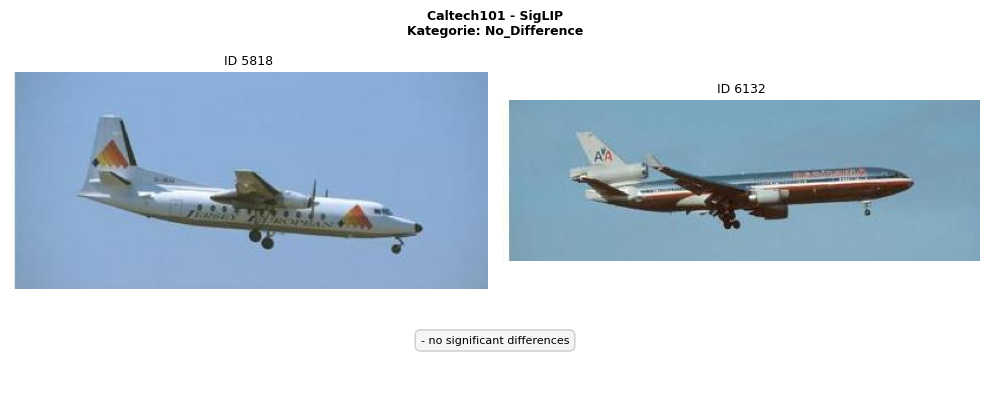

--------------------------------------------------------------------------------


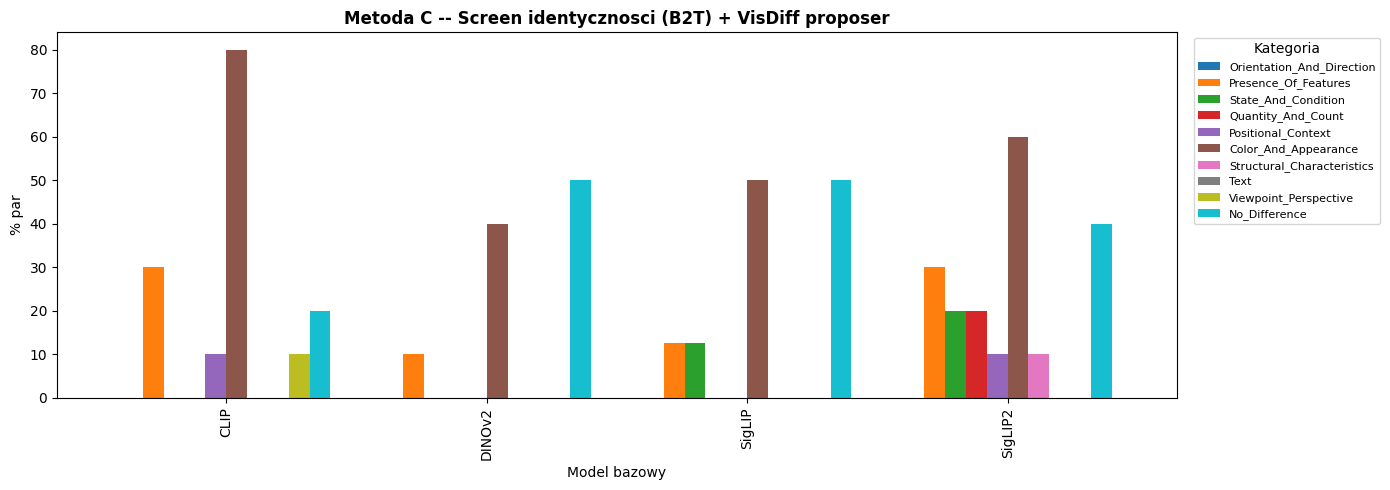

,Orientation_And_Direction,Presence_Of_Features,State_And_Condition,Quantity_And_Count,Positional_Context,Color_And_Appearance,Structural_Characteristics,Text,Viewpoint_Perspective,No_Difference
base_name,,,,,,,,,,
CLIP,0.0,30.0,0.0,0.0,10.0,80.0,0.0,0.0,10.0,20.0
DINOv2,0.0,10.0,0.0,0.0,0.0,40.0,0.0,0.0,0.0,50.0
SigLIP,0.0,12.5,12.5,0.0,0.0,50.0,0.0,0.0,0.0,50.0
SigLIP2,0.0,30.0,20.0,20.0,10.0,60.0,10.0,0.0,0.0,40.0


In [ ]:
n_identical = results_c["identical_by_qwen"].sum()
n_total     = len(results_c)
print(f"Odrzucono jako identyczne: {n_identical}/{n_total} par ({n_identical/n_total*100:.1f}%)")

show_results(results_c, desc_col="diff_bullets",
             dataset_name="Caltech101", model_name="SigLIP", n=10)
plot_category_bars(results_c, "Metoda C -- Screen identycznosci (B2T) + VisDiff proposer")

### Czyszczenie cache

In [ ]:
# import shutil
# shutil.rmtree(CACHE_DIR, ignore_errors=True)
# print(f'Cache usuniety: {CACHE_DIR}')